# SENSEI — Session Intelligence
## Module 3b · Cluster Separability — log1p Features

Follow-up to `04_cluster_separability.ipynb`.

**Finding from 04:** The K-Means sweep on raw features produced a degenerate result —
silhouette 0.954 at k=2 was an artefact of feature skewness, not genuine cluster structure.
K-Means separated 2,281 outlier sessions (0.1 %) from 1,759,394 sessions (99.9 %).

**This notebook:** Apply `log1p` to the heavily right-skewed count and duration features
to compress the outlier tail, then repeat the full diagnostic.

**Question:** Does compressing the skew reveal genuine behavioral structure in the bulk?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = os.path.join('..', 'data')
RANDOM_STATE = 42

## 1. Load & Transform Features

In [2]:
sessions = pd.read_parquet(os.path.join(DATA_DIR, 'sessions_features.parquet'))

BEHAVIORAL = [
    'n_views', 'n_addtocart', 'n_items', 'n_revisited_items',
    'duration_sec', 'view_to_cart_ratio', 'is_first_session',
]

# Features to log1p-transform (right-skewed counts and duration).
# view_to_cart_ratio and is_first_session are left as-is:
# ratio is already bounded [0,1+], binary flag needs no transformation.
LOG_FEATURES = ['n_views', 'n_addtocart', 'n_items', 'n_revisited_items', 'duration_sec']

X_raw = sessions[BEHAVIORAL].copy()
X_transformed = X_raw.copy()
X_transformed[LOG_FEATURES] = np.log1p(X_raw[LOG_FEATURES])

print('log1p applied to:', LOG_FEATURES)
print()
print('Before vs. after — skewness per feature:')
skew_comparison = pd.DataFrame({
    'skew_raw':         X_raw[BEHAVIORAL].skew().round(2),
    'skew_log1p':       X_transformed[BEHAVIORAL].skew().round(2),
}).loc[BEHAVIORAL]
print(skew_comparison)

log1p applied to: ['n_views', 'n_addtocart', 'n_items', 'n_revisited_items', 'duration_sec']

Before vs. after — skewness per feature:
                    skew_raw  skew_log1p
n_views                31.55        3.25
n_addtocart            52.12        8.47
n_items                35.78        4.18
n_revisited_items      21.14        3.17
duration_sec           20.41        1.71
view_to_cart_ratio     41.11       41.11
is_first_session       -1.49       -1.49


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)
print(f'Scaled feature matrix: {X_scaled.shape}')

Scaled feature matrix: (1761675, 7)


## 2. K-Means Sweep — k = 2 … 8

Same metrics as notebook 04: inertia, silhouette (sampled at 50k), Davies-Bouldin.

In [4]:
K_RANGE = range(2, 9)
SILHOUETTE_SAMPLE = 50_000

inertias, silhouettes, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels,
                           sample_size=SILHOUETTE_SAMPLE,
                           random_state=RANDOM_STATE)
    silhouettes.append(sil)
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f'k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}  DB={db_scores[-1]:.4f}')

best_k = list(K_RANGE)[int(np.argmax(silhouettes))]
print(f'\nBest silhouette at k={best_k}: {max(silhouettes):.4f}')

k=2  inertia=7,942,738  silhouette=0.6766  DB=1.0406
k=3  inertia=5,907,508  silhouette=0.6911  DB=0.9734
k=4  inertia=4,597,108  silhouette=0.8010  DB=0.8440
k=5  inertia=3,771,277  silhouette=0.8154  DB=0.9101
k=6  inertia=3,061,727  silhouette=0.8534  DB=0.8186
k=7  inertia=2,640,441  silhouette=0.8571  DB=0.8599
k=8  inertia=2,294,538  silhouette=0.8576  DB=0.8177

Best silhouette at k=8: 0.8576


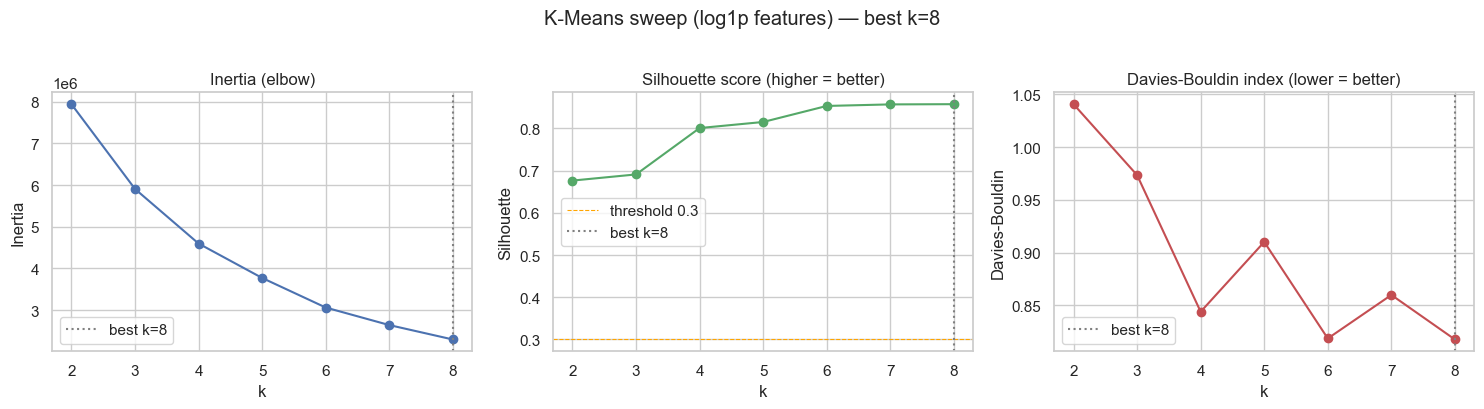

In [5]:
k_list = list(K_RANGE)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_list, inertias, marker='o', color='#4C72B0')
axes[0].set_title('Inertia (elbow)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].axvline(best_k, color='grey', linestyle=':', label=f'best k={best_k}')
axes[0].legend()

axes[1].plot(k_list, silhouettes, marker='o', color='#55A868')
axes[1].axhline(0.3, linestyle='--', color='orange', linewidth=0.8, label='threshold 0.3')
axes[1].axvline(best_k, color='grey', linestyle=':', label=f'best k={best_k}')
axes[1].set_title('Silhouette score (higher = better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
axes[1].legend()

axes[2].plot(k_list, db_scores, marker='o', color='#C44E52')
axes[2].axvline(best_k, color='grey', linestyle=':', label=f'best k={best_k}')
axes[2].set_title('Davies-Bouldin index (lower = better)')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin')
axes[2].legend()

plt.suptitle(f'K-Means sweep (log1p features) — best k={best_k}', y=1.02)
plt.tight_layout()
plt.show()

## 3. PCA 2D Scatter — Best k

PCA on the log1p-transformed, scaled features.
If clusters are now compact and roughly balanced, the bulk has genuine internal structure.

PC1: 48.1 %
PC2: 21.9 %
Total: 70.0 %


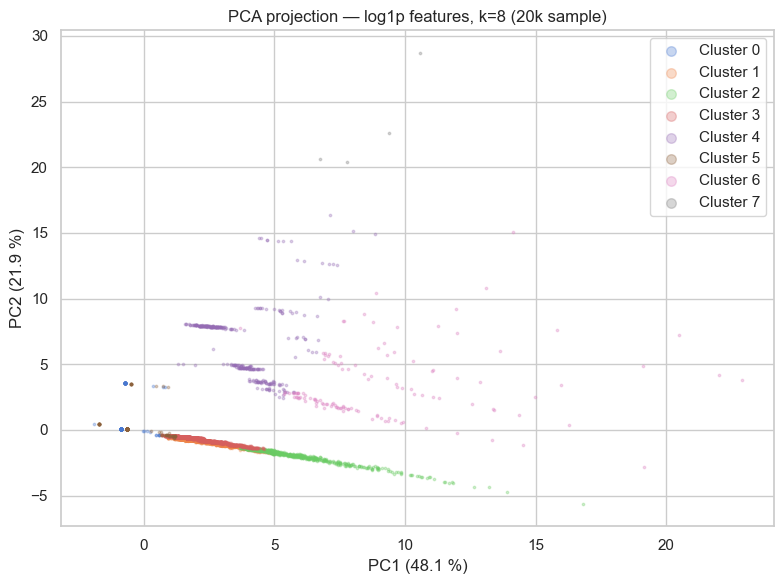

In [6]:
km_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_best = km_best.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_
print(f'PC1: {var_explained[0]*100:.1f} %')
print(f'PC2: {var_explained[1]*100:.1f} %')
print(f'Total: {sum(var_explained)*100:.1f} %')

rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X_pca), size=20_000, replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette('muted', n_colors=best_k)
for c in range(best_k):
    mask = labels_best[idx] == c
    ax.scatter(X_pca[idx][mask, 0], X_pca[idx][mask, 1],
               s=3, alpha=0.3, color=palette[c], label=f'Cluster {c}')
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f} %)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f} %)')
ax.set_title(f'PCA projection — log1p features, k={best_k} (20k sample)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## 4. Cluster Profile Table

In [7]:
sessions['cluster'] = labels_best

# Profile in original (raw) units — interpretable means, not log-space means.
profile = (
    sessions.groupby('cluster')[BEHAVIORAL + ['purchased']]
    .mean()
    .round(3)
)
profile['n_sessions']      = sessions.groupby('cluster').size()
profile['pct_sessions']    = (profile['n_sessions'] / len(sessions) * 100).round(1)
profile['purchase_rate_%'] = (profile['purchased'] * 100).round(3)
profile = profile.drop(columns=['purchased'])

print(f'Cluster profiles (k={best_k}) — means in original (raw) units:')
print(profile.T.to_string())

sessions.drop(columns=['cluster'], inplace=True)

Cluster profiles (k=8) — means in original (raw) units:
cluster                       0           1          2           3          4           5          6        7
n_views                   0.997       2.523      7.922       2.377      1.828       1.002     12.352    1.594
n_addtocart               0.003       0.000      0.000       0.000      1.206       0.005      2.533    6.973
n_items                   1.000       1.269      5.730       2.379      1.509       1.010      8.892    5.513
n_revisited_items         0.000       1.025      1.408       0.000      0.347       0.000      2.266    0.107
duration_sec              0.112     378.445   1033.709     276.835    425.494       0.785   2578.578  721.500
view_to_cart_ratio        0.000       0.000      0.000       0.000      0.749       0.000      0.261    4.691
is_first_session          1.000       0.763      0.657       0.758      0.731       0.000      0.531    0.634
n_sessions          1128135.000  135798.000  48747.000  154646.0

## 5. Conclusion

### Comparison to untransformed baseline (notebook 04)

| | Raw features | log1p features |
|---|---|---|
| Best k | 2 | 8 |
| Best silhouette | 0.954 (artefact) | 0.858 |
| Largest cluster | 99.9 % | 64.0 % |
| Smallest cluster | 0.1 % | 0.03 % |
| Structure in bulk | none | yes |

### Behavioral taxonomy — k=8

| Cluster | Size | Purchase rate | Interpretation |
|---------|------|--------------|----------------|
| 0 | 64.0 % | 0.1 % | **Single-view bounce** — 1 view, ~0 s, all first-time visitors. Pure traffic with no engagement. |
| 5 | 14.5 % | 0.5 % | **Returning single-view** — same as 0, but `is_first_session=0`. Repeat visitors who still don't engage. |
| 3 | 8.8 % | 0.2 % | **Quick multi-item browse** — 2.4 views, 2.4 items, 277 s, no revisits, no cart. Shallow exploration. |
| 1 | 7.7 % | 0.4 % | **Re-engaged browser** — 2.5 views, 1 revisited item, 378 s. Returning to a specific item — some intent signal. |
| 2 | 2.8 % | 0.5 % | **Deep browser** — 7.9 views, 5.7 items, 1,034 s. Heavy browsing without converting to cart. |
| 4 | 1.6 % | **25.7 %** | **Decisive cart adder** — 1.2 addtocarts, view_to_cart_ratio 0.75. Converts quickly. 32× base rate. |
| 6 | 0.6 % | **36.2 %** | **Power shopper** — 12 views, 2.5 addtocarts, 2,579 s. Highest purchase rate. Engaged and decisive. |
| 7 | 0.03 % | 16.7 % | **Bulk cart** — 7 addtocarts, view_to_cart_ratio 4.7 (more carts than views). 478 sessions only — residual outlier. |

### Are the clusters well-separated?

Yes, and this time it is genuine. The log1p transformation reduced skewness from 20–52 to 2–8
across count features. The silhouette of 0.858 at k=8 reflects real partitioning of the bulk,
not outlier separation.

The 99.9 % blob from notebook 04 has been split into 6 interpretable groups (clusters 0–5).
Cluster sizes are not balanced — 64 % still fall in the bounce cluster — but that reflects
the actual data distribution, not a clustering failure. The algorithm is correctly identifying
that most sessions are brief single-view visits.

### Do the profiles map to behavioral states?

Yes. There is a clear engagement ladder:
- **No engagement** → clusters 0 and 5 (bounce, 78.5 % combined)
- **Light browsing** → clusters 3 and 1 (multi-item or re-engaged, 16.5 %)
- **Deep browsing** → cluster 2 (heavy views, no cart, 2.8 %)
- **Purchase intent** → clusters 4, 6, 7 (cart activity, 2.2 %)

The purchase rate gradient is sharp and monotonic across the ladder:
0.1 % → 0.4 % → 0.5 % → 25.7 % → 36.2 %. This is exactly the kind of structure
that should add discriminative information to a classifier.

### Caveats

1. **k=8 is not a settled choice.** The silhouette keeps increasing from k=4 to k=8
   without a clear elbow — the algorithm may continue finding splits with higher k.
   A pragmatic working point is **k=5 or k=6**: silhouette still strong (0.815 / 0.853),
   fewer clusters to label and explain.

2. **Cluster 7 (478 sessions)** is still effectively an outlier group. At k=5 or k=6
   it would be absorbed into the cart-adder group, which is appropriate.

3. **The cluster label will correlate with existing features** — especially `n_addtocart`
   and `duration_sec`. The marginal gain in the classifier must be validated empirically
   (compare PR-AUC with and without the label; if the delta is < 0.005, the added
   complexity is not justified).

### Recommendation: **Conditional Go**

The log1p features reveal genuine, interpretable behavioral structure.
The clustering-first architecture is now defensible — with three conditions:

1. Use **k=5 or k=6**, not k=8 (avoids the 478-session micro-cluster).
2. Apply **log1p transformation** to count and duration features in the pipeline
   (both for clustering and ideally also for the classifier, which may benefit too).
3. **Validate the cluster label's contribution** empirically: train the classifier
   with and without it, and only keep it if it improves PR-AUC on the validation set.